# Regresja 
Estymacja ceny mieszkań na podstawie zbioru danych **AmesHousing**

### Importowanie potrzebnych bibliotek

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Wczytywanie danych

In [84]:
df = pd.read_csv("domy.csv", index_col=[0], na_values=['?'])
df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### Preprocessing danych

In [85]:
df.columns

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd',
       'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'Wo

Gradacja zmiennej *Electical* jest niejednoznaczna

In [86]:
missing_values = df.isna().sum()
missing_values[missing_values > 0]

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

<Axes: >

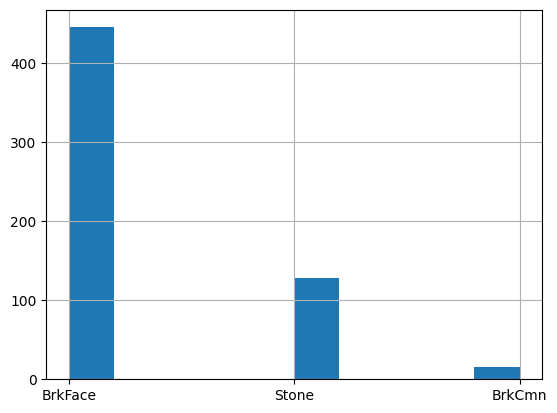

In [87]:
df.MasVnrType.hist()

##### Dealing with false N/A values

In [88]:
df.loc[df.LotFrontage.isna(), "LotFrontage"] = 0

##### Missing values

In [89]:
print("MasVnrArea")
print(f"Values equal to zero: {df.MasVnrArea[df.MasVnrArea == 0].count()}   <-- lack of masonry veneer")
print(f"Missing values:")
print(df.MasVnrArea[df.MasVnrArea.isna()])


MasVnrArea
Values equal to zero: 861   <-- lack of masonry veneer
Missing values:
Id
235    NaN
530    NaN
651    NaN
937    NaN
974    NaN
978    NaN
1244   NaN
1279   NaN
Name: MasVnrArea, dtype: float64


Basement quality: lack of *Poor* value specified in documentation

<Axes: >

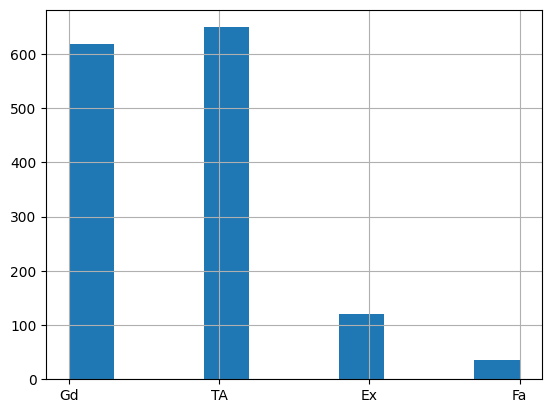

In [90]:
df.BsmtQual.hist()

Basement condition: lack of *Excellent* value specified in documentation

<Axes: >

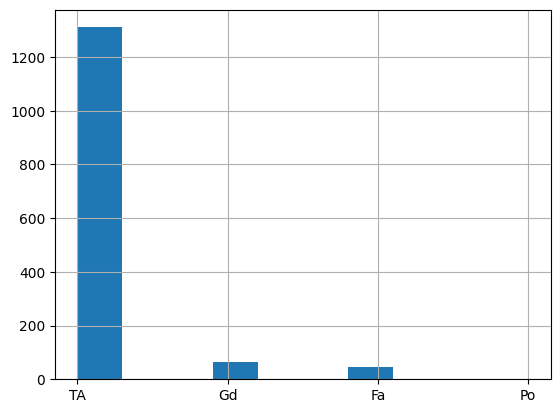

In [91]:
df.BsmtCond.hist()

In [92]:
df.columns

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd',
       'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'Wo

##### One-hot encoding
TODO: Condition 1 and 2 merge, and Exterior 1/2
Misc feature to set as val

In [ ]:
nominal_columns = ["MSSubClass", "MSZoning", "Street", "LandContour", "LotConfig", 
                   "Neighborhood", "BldgType", "HouseStyle", "RoofStyle", "RoofMatl", "Foundation",
                   "Heating", "CentralAir", "SaleType", "SaleCondition"]
nominal_columns_na = ["Alley", "MasVnrType", "GarageType"]
df = pd.get_dummies(df, drop_first=True, columns=nominal_columns)
df = pd.get_dummies(df, drop_first=False, columns=nominal_columns_na)

In [94]:
df.describe()

,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,57.623288,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,34.664304,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,0.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,42.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,63.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,79.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [95]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 1 to 1460
Columns: 170 entries, LotFrontage to GarageType_Detchd
dtypes: bool(108), float64(3), int64(33), str(26)
memory usage: 861.3 KB


<Axes: title={'center': 'SalePrice'}, xlabel='Condition2'>

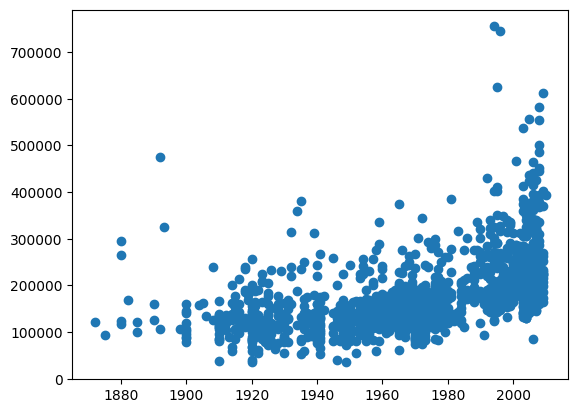

<Figure size 640x480 with 0 Axes>

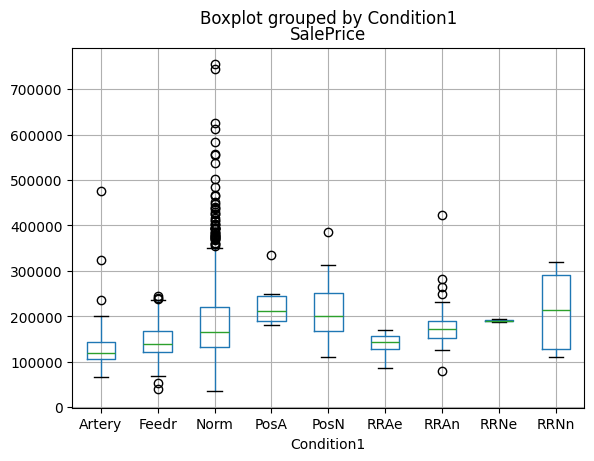

<Figure size 640x480 with 0 Axes>

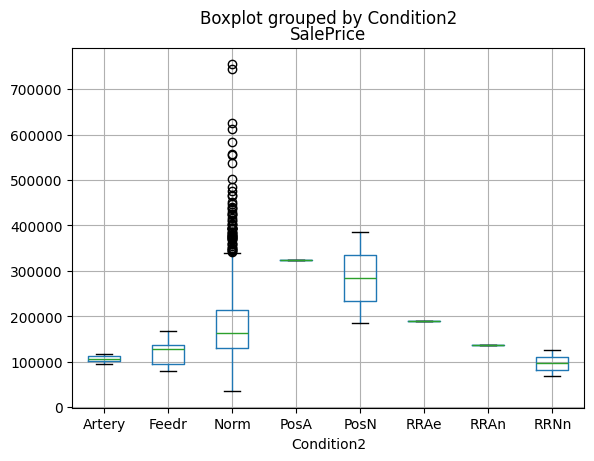

In [96]:
plt.scatter(df.YearBuilt, df.SalePrice)
plt.figure()
df.boxplot(by="Condition1", column="SalePrice")
plt.figure()
df.boxplot(by="Condition2", column="SalePrice")

### Analiza korelacji

,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,...,Alley_Pave,MasVnrType_BrkCmn,MasVnrType_BrkFace,MasVnrType_Stone,GarageType_2Types,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd
LotFrontage,1.000000,0.100739,0.176561,-0.053457,0.036853,0.078686,0.105255,0.076670,-0.009312,0.160829,...,-0.064912,-0.032411,-0.036471,0.121902,-0.000846,0.075110,0.018514,0.005743,0.024089,-0.086664
LotArea,0.100739,1.000000,0.105806,-0.005636,0.014228,0.013788,0.104160,0.214103,0.111170,-0.002618,...,-0.077747,0.115884,-0.016388,0.038328,0.043358,0.122839,-0.000956,0.037552,0.009136,-0.126094
OverallQual,0.176561,0.105806,1.000000,-0.091932,0.572323,0.550684,0.411876,0.239666,-0.059119,0.308159,...,0.038768,-0.061362,0.224727,0.331584,-0.051079,0.357994,-0.025734,0.198299,-0.100601,-0.337227
OverallCond,-0.053457,-0.005636,-0.091932,1.000000,-0.375983,0.073741,-0.128101,-0.046231,0.040229,-0.136841,...,-0.020830,-0.016059,-0.082966,-0.125495,-0.052473,-0.113612,-0.015926,-0.063721,-0.032867,0.183224
YearBuilt,0.036853,0.014228,0.572323,-0.375983,1.000000,0.592855,0.315707,0.249503,-0.049107,0.149040,...,-0.016612,-0.040048,0.275280,0.289626,-0.038512,0.472229,-0.043454,0.201547,-0.056346,-0.487130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GarageType_Attchd,0.075110,0.122839,0.357994,-0.113612,0.472229,0.269221,0.174529,0.277367,0.061764,0.069024,...,-0.121926,0.014695,0.235990,0.112159,-0.078006,1.000000,-0.139437,-0.307537,-0.095636,-0.729272
GarageType_Basment,0.018514,-0.000956,-0.025734,-0.015926,-0.043454,-0.039664,-0.010213,-0.005503,0.017635,-0.039097,...,-0.019518,-0.011699,0.029001,-0.014227,-0.007376,-0.139437,1.000000,-0.029081,-0.009043,-0.068961
GarageType_BuiltIn,0.005743,0.037552,0.198299,-0.063721,0.201547,0.184043,0.117312,-0.069965,-0.062664,0.063465,...,-0.043049,-0.025803,0.044878,0.104660,-0.016269,-0.307537,-0.029081,1.000000,-0.019946,-0.152097
GarageType_CarPort,0.024089,0.009136,-0.100601,-0.032867,-0.056346,-0.065208,-0.036368,-0.014908,0.064902,-0.070470,...,-0.013387,0.165535,-0.052148,-0.024414,-0.005059,-0.095636,-0.009043,-0.019946,1.000000,-0.047298


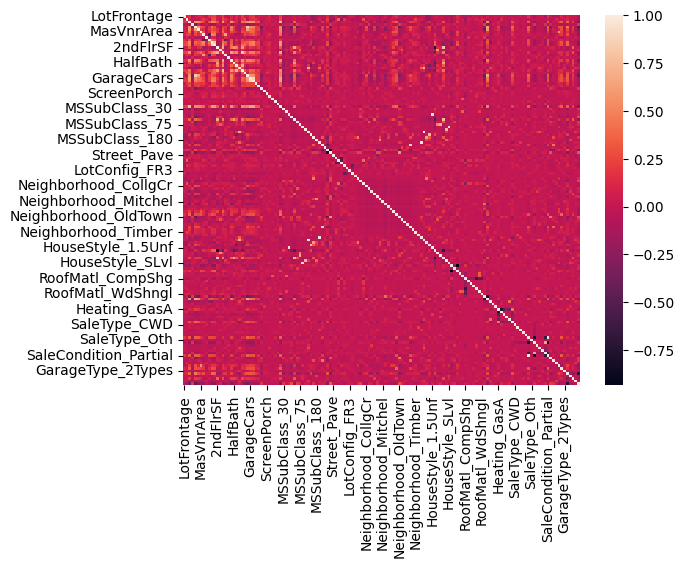

In [97]:
sns.heatmap(df.corr(numeric_only=True))
df.corr(numeric_only=True)

Duże znaczenie bezpośrenie na cenę końcową mają ogólna jakość mieszkania oraz powierzchnia mieszkalna.
Zauważalne znaczenie bezpośrednie mają rok produkcji i remontu, powierzchnia piwnicy, pojemność garażu, ilość pełnych łazienek, obecność kominka.

(array([  5.,  10.,  34., 141., 401., 423., 260., 130.,  43.,   9.]),
 array([10.46024211, 10.74876859, 11.03729507, 11.32582155, 11.61434804,
        11.90287452, 12.191401  , 12.47992748, 12.76845396, 13.05698045,
        13.34550693]),
 <BarContainer object of 10 artists>)

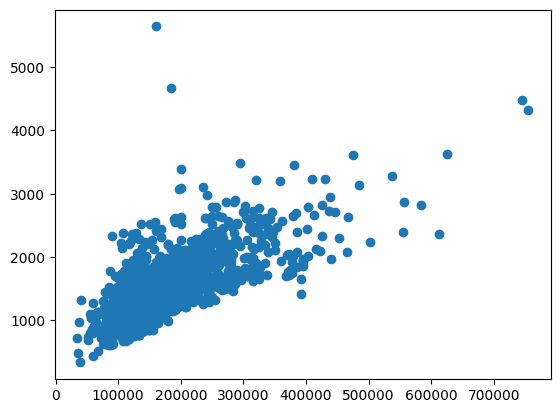

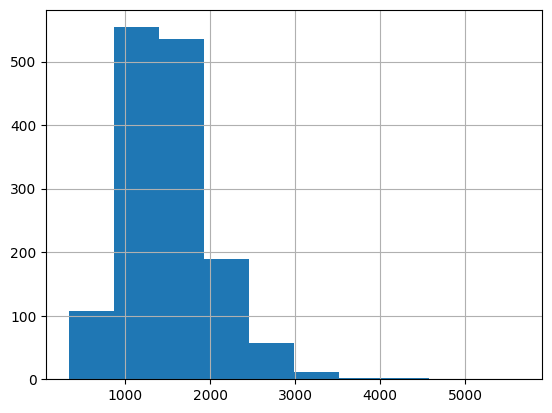

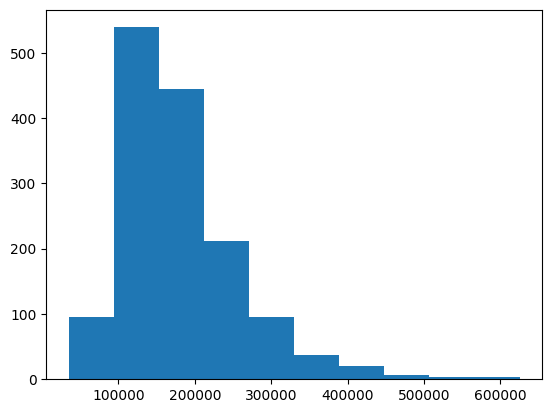

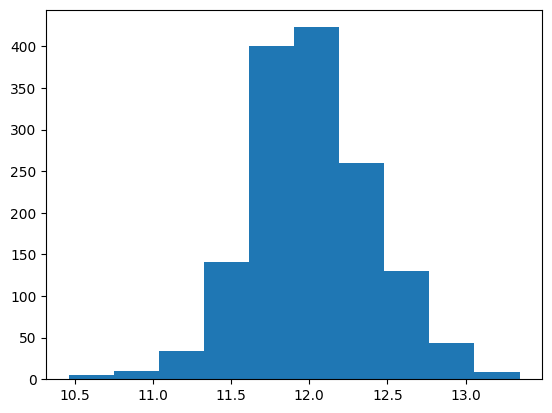

In [98]:
plt.scatter(df.SalePrice, df.GrLivArea)
plt.figure()
df["GrLivArea"].hist()
df = df[df.GrLivArea <= 4000]
plt.figure()
plt.hist(df.SalePrice)
df.SalePrice = np.log(df.SalePrice)
plt.figure()
plt.hist(df.SalePrice)

In [99]:
from sklearn.preprocessing import OneHotEncoder
Y = df.SalePrice
X = df.drop(["SalePrice"], axis=1)
X.LotFrontage = X.LotFrontage.astype(np.float32)
X.MasVnrArea = X.MasVnrArea.astype(np.float32)
X_num = df.select_dtypes(include='int64').join(df.select_dtypes(include='float64'))
X_num

,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,...,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,LotFrontage,MasVnrArea,GarageYrBlt,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,8450,7,5,2003,2003,706,0,150,856,856,...,0,0,0,0,2,2008,65.0,196.0,2003.0,12.247694
2,9600,6,8,1976,1976,978,0,284,1262,1262,...,0,0,0,0,5,2007,80.0,0.0,1976.0,12.109011
3,11250,7,5,2001,2002,486,0,434,920,920,...,0,0,0,0,9,2008,68.0,162.0,2001.0,12.317167
4,9550,7,5,1915,1970,216,0,540,756,961,...,0,0,0,0,2,2006,60.0,0.0,1998.0,11.849398
5,14260,8,5,2000,2000,655,0,490,1145,1145,...,0,0,0,0,12,2008,84.0,350.0,2000.0,12.429216
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,7917,6,5,1999,2000,0,0,953,953,953,...,0,0,0,0,8,2007,62.0,0.0,1999.0,12.072541
1457,13175,6,6,1978,1988,790,163,589,1542,2073,...,0,0,0,0,2,2010,85.0,119.0,1978.0,12.254863
1458,9042,7,9,1941,2006,275,0,877,1152,1188,...,0,0,0,2500,5,2010,66.0,0.0,1941.0,12.493130
